In [2]:
import pandas as pd
import numpy as np
import rasterio
from rasterio.plot import show
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

In [12]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']   # 使用黑体
plt.rcParams['axes.unicode_minus'] = False     # 解决坐标轴负号显示问题


In [ ]:
class Sentinel1IceClassifier:
    def __init__(self, selected_features=None):
        self.rf_model = None
        self.scaler = StandardScaler()
        
        # 所有可用的特征选项
        self.available_features = {
            'HH': 'HH波段（水平发射-水平接收）',
            'HV': 'HV波段（水平发射-垂直接收）',
            'HH_div_HV': 'HH/HV比值',
            'HH_minus_HV': 'HH-HV差值', 
            'ANGLE': '入射角',
            'HH_norm': 'HH标准化',
            'HV_norm': 'HV标准化',
            'sum_div_diff': '总和除差值'
        }
        
        # 默认特征组合（如果没有指定）
        if selected_features is None:
            self.feature_names = ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE']
        else:
            self.feature_names = selected_features
        
        # 验证选择的特征是否有效
        for feature in self.feature_names:
            if feature not in self.available_features:
                raise ValueError(f"特征 '{feature}' 不在可用特征列表中")
        
        # TIFF波段名称（保持完整列表用于文件读取）
        self.tiff_band_names = ['HH', 'HV', 'ANGLE', 'SIC', 'HH_norm', 'HV_norm', 
                               'HH_div_HV', 'HH_minus_HV', 'sum_div_diff']
        
        self.class_names = ['ice', 'lead', 'refrozen']
        self.class_colors = ["#1f76b400", "#020201", "#1939ee"]  # 蓝色、橙色、绿色
        
        print(f"初始化分类器，使用特征: {self.feature_names}")
     
    def print_available_features(self):
        """
        打印所有可用的特征选项
        """
        print("\n=== 可用特征列表 ===")
        for feature, description in self.available_features.items():
            status = "✓" if feature in self.feature_names else " "
            print(f"[{status}] {feature}: {description}")
        
        print(f"\n当前选择的特征: {self.feature_names}")   
        
        
    def update_selected_features(self, new_features):
        """
        更新选择的特征
        """
        # 验证新特征
        for feature in new_features:
            if feature not in self.available_features:
                raise ValueError(f"特征 '{feature}' 不在可用特征列表中")
        
        self.feature_names = new_features
        print(f"特征已更新为: {self.feature_names}")
        
        # 如果已有模型，需要重新训练
        if self.rf_model is not None:
            print("警告: 特征已更改，需要重新训练模型")
            self.rf_model = None
            
            
            
    # def _calculate_derived_features(self, data):
    #     """统一计算衍生特征。"""
    #     is_df = isinstance(data, pd.DataFrame)
    #     hh = data['HH']; hv = data['HV']
    #     if is_df:
    #         with np.errstate(divide='ignore', invalid='ignore'):
    #             data['HH_div_HV'] = (hh / hv).replace([np.inf, -np.inf], 0).fillna(0)
    #             s = hh + hv; d = hh - hv
    #             data['sum_div_diff'] = (s / (d + 1e-6)).replace([np.inf, -np.inf], 0).fillna(0)
    #     else:
    #         with np.errstate(divide='ignore', invalid='ignore'):
    #             data['HH_div_HV'] = np.divide(hh, hv, out=np.zeros_like(hh, dtype=float), where=hv!=0)
    #             s = hh + hv; d = hh - hv
    #             data['sum_div_diff'] = np.divide(s, d + 1e-6, out=np.zeros_like(s, dtype=float), where=(d + 1e-6)!=0)
    #     data['HH_minus_HV'] = hh - hv
    #     return data
        
    def load_and_merge_samples(self, csv_files):
        """
        加载并合并多个日期的样本CSV文件
        """
        print("正在加载样本数据...")
        all_samples = []
        
        if isinstance(csv_files, str):
            csv_files = [csv_files]
            
        for csv_file in csv_files:
            df = pd.read_csv(csv_file)
            print(f"加载文件: {csv_file}, 样本数: {len(df)}")
            all_samples.append(df)
        
        # 合并所有样本
        merged_samples = pd.concat(all_samples, ignore_index=True)
        print(f"合并后总样本数: {len(merged_samples)}")
        
        # 显示类别分布
        class_counts = merged_samples['class'].value_counts().sort_index()
        print("\n类别分布:")
        for class_id, count in class_counts.items():
            print(f"  {self.class_names[class_id-1]} (class {class_id}): {count} 样本")
        
        return merged_samples
    
    def prepare_training_data(self, samples_df):
        """
        准备训练数据，使用新的CSV格式
        """
        print("\n准备训练数据...")
        
        # 创建特征名称映射 (CSV列名 -> 标准特征名)
        csv_feature_mapping = {
            'HH': 'HH',
            'HV': 'HV', 
            # 移除 HH_HV 映射，因为SAR影像中没有这个波段
            'HH_div_HV': 'HH_div_HV',
            'HH_minus_HV': 'HH_minus_HV',
            'indicenceAngle': 'ANGLE',  # 注意CSV中的拼写
            'HH_norm': 'HH_norm',
            'HV_norm': 'HV_norm',
            'sum_div_diff': 'sum_div_diff'
        }
         # 只选择当前配置使用的特征
        selected_csv_cols = []
        missing_features = []
        
        for feature in self.feature_names:
            # 找到对应的CSV列名
            csv_col = None
            for csv_name, std_name in csv_feature_mapping.items():
                if std_name == feature:
                    csv_col = csv_name
                    break
            
            if csv_col and csv_col in samples_df.columns:
                selected_csv_cols.append(csv_col)
            else:
                missing_features.append(feature)
                print(f"警告: CSV中未找到特征 '{feature}' 对应的列")
        
        if missing_features:
            print(f"缺失的特征: {missing_features}")
            print("将从训练中排除这些特征")
            # 更新特征列表，移除缺失的特征
            self.feature_names = [f for f in self.feature_names if f not in missing_features]
        
        if not selected_csv_cols:
            raise ValueError("没有找到任何可用的特征列")
        
        # 选择特征列
        X = samples_df[selected_csv_cols].copy()
        y = samples_df['class'].copy()
        
        # 重命名列以匹配标准特征名
        rename_mapping = {}
        for csv_col in selected_csv_cols:
            for csv_name, std_name in csv_feature_mapping.items():
                if csv_name == csv_col:
                    rename_mapping[csv_col] = std_name
                    break
        
        X.rename(columns=rename_mapping, inplace=True)

        # 检查缺失值
        if X.isnull().any().any():
            print("警告: 发现缺失值，将使用均值填充")
            X = X.fillna(X.mean())
            
        X = X[self.feature_names]
        print(f"实际使用的特征: {list(X.columns)}")
        print(f"特征矩阵形状: {X.shape}")
        print(f"目标变量形状: {y.shape}")
        
        return X, y
    
    def load_tiff_bands(self, tiff_path):
        """
        从TIFF文件加载所有波段数据
        """
        print(f"\n加载TIFF文件: {tiff_path}")
        
        with rasterio.open(tiff_path) as src:
            # 读取所有波段
            bands_data = src.read()  # 形状: (bands, height, width)
            profile = src.profile
            
            print(f"TIFF文件信息:")
            print(f"  波段数: {bands_data.shape[0]}")
            print(f"  影像尺寸: {bands_data.shape[1]} x {bands_data.shape[2]}")
            print(f"  数据类型: {bands_data.dtype}")
            
            # 创建波段字典
            bands_dict = {}
            for i, band_name in enumerate(self.tiff_band_names):
                if i < bands_data.shape[0]:
                    bands_dict[band_name] = bands_data[i]
                    print(f"  波段 {i+1}: {band_name}")
                else:
                    print(f"  警告: 波段 {band_name} 超出可用波段数")
        
        return bands_dict, profile
    
    def test_different_trees(self, X, y, n_trees_list=[10, 50, 100, 200, 300, 500]):
        """
        测试不同数量树的分类效果
        """
        print("\n测试不同数量的树...")
        results = []
        
        # 分割训练和测试数据
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        for n_trees in n_trees_list:
            print(f"测试 {n_trees} 棵树...")
            
            # 创建随机森林模型
            rf = RandomForestClassifier(
                n_estimators=n_trees,
                random_state=42,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                n_jobs=-1
            )
            
            # 训练模型
            rf.fit(X_train, y_train)
            
            # 预测
            y_pred = rf.predict(X_test)
            
            # 计算准确率
            accuracy = accuracy_score(y_test, y_pred)
            
            # 交叉验证
            cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
            
            results.append({
                'n_trees': n_trees,
                'test_accuracy': accuracy,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'model': rf
            })
            
            print(f"  测试准确率: {accuracy:.4f}")
            print(f"  交叉验证准确率: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        
        # 创建结果DataFrame
        results_df = pd.DataFrame(results)
        
        # 绘制结果
        self.plot_tree_comparison(results_df)
        
        # 找到最佳模型
        best_idx = results_df['cv_mean'].idxmax()
        best_model = results_df.iloc[best_idx]
        
        print(f"\n最佳模型: {best_model['n_trees']} 棵树")
        print(f"最佳交叉验证准确率: {best_model['cv_mean']:.4f}")
        
        return results_df, best_model['model']
    
    def plot_tree_comparison(self, results_df):
        """
        绘制不同树数量的比较图
        """
        plt.figure(figsize=(12, 8))
        
        # 子图1: 准确率比较
        plt.subplot(2, 2, 1)
        plt.plot(results_df['n_trees'], results_df['test_accuracy'], 'bo-', label='测试准确率')
        plt.plot(results_df['n_trees'], results_df['cv_mean'], 'ro-', label='交叉验证准确率')
        plt.xlabel('树的数量')
        plt.ylabel('准确率')
        plt.title('不同树数量的分类准确率')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 子图2: 交叉验证误差条
        plt.subplot(2, 2, 2)
        plt.errorbar(results_df['n_trees'], results_df['cv_mean'], 
                    yerr=results_df['cv_std'], fmt='o-', capsize=5)
        plt.xlabel('树的数量')
        plt.ylabel('交叉验证准确率')
        plt.title('交叉验证准确率 (带标准差)')
        plt.grid(True, alpha=0.3)
        
        # 子图3: 数值表格
        plt.subplot(2, 2, 3)
        plt.axis('tight')
        plt.axis('off')
        table_data = results_df[['n_trees', 'test_accuracy', 'cv_mean', 'cv_std']].round(4)
        table = plt.table(cellText=table_data.values,
                         colLabels=['树数量', '测试准确率', 'CV均值', 'CV标准差'],
                         cellLoc='center',
                         loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        
        plt.tight_layout()
        plt.show()
    
    def train_final_model(self, X, y, model_params=None):
        """
        训练最终模型
        """
        print("\n训练最终模型...")
        
        if model_params is None:
            # 使用默认参数
            self.rf_model = RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                n_jobs=-1
            )
        else:
            self.rf_model = model_params
        
        # 训练模型
        self.rf_model.fit(X, y)
        
        # 特征重要性
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': self.rf_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("特征重要性:")
        for _, row in feature_importance.iterrows():
            print(f"  {row['feature']}: {row['importance']:.4f}")
        
        # 绘制特征重要性
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_importance, x='importance', y='feature')
        plt.title('特征重要性')
        plt.xlabel('重要性得分')
        plt.tight_layout()
        plt.show()
        
        return self.rf_model
    
    def evaluate_model(self, X, y):
        """
        评估模型性能
        """
        print("\n评估模型性能...")
        
        # 分割数据
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        # 预测
        y_pred = self.rf_model.predict(X_test)
        
        # 分类报告
        print("\n分类报告:")
        report = classification_report(y_test, y_pred, 
                                     target_names=self.class_names,
                                     output_dict=True)
        print(classification_report(y_test, y_pred, target_names=self.class_names))
        
        # 混淆矩阵
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', 
                   xticklabels=self.class_names, 
                   yticklabels=self.class_names,
                   cmap='Blues')
        plt.title('混淆矩阵')
        plt.xlabel('预测类别')
        plt.ylabel('真实类别')
        plt.show()
        
        return report
    
    def classify_masked_sentinel1(self, tiff_path, output_path=None):
        """
        对已经masked的Sentinel-1 TIFF进行分类
        """
        print("\n开始对masked Sentinel-1影像进行分类...")
        
        # 加载TIFF数据
        bands_dict, profile = self.load_tiff_bands(tiff_path)
        
        # 获取影像尺寸
        sample_band = list(bands_dict.values())[0]
        h, w = sample_band.shape
        
        # 准备用于分类的特征（使用当前选择的特征）
        feature_arrays = []
        available_features = []
        
        print("检查特征可用性:")
        for feature_name in self.feature_names:
            if feature_name in bands_dict:
                feature_arrays.append(bands_dict[feature_name])
                available_features.append(feature_name)
                print(f"  ✓ {feature_name}: 可用")
            else:
                print(f"  ✗ {feature_name}: 不可用")
                # 尝试计算衍生特征
                if feature_name == 'HH_div_HV' and 'HH' in bands_dict and 'HV' in bands_dict:
                    hh_data = bands_dict['HH']
                    hv_data = bands_dict['HV']
                    # 避免除零
                    calculated_band = np.divide(hh_data, hv_data, 
                                              out=np.zeros_like(hh_data), 
                                              where=hv_data!=0)
                    feature_arrays.append(calculated_band)
                    available_features.append(feature_name)
                    print(f"    → 从HH/HV计算得到 {feature_name}")
                
                elif feature_name == 'HH_minus_HV' and 'HH' in bands_dict and 'HV' in bands_dict:
                    calculated_band = bands_dict['HH'] - bands_dict['HV']
                    feature_arrays.append(calculated_band)
                    available_features.append(feature_name)
                    print(f"    → 从HH-HV计算得到 {feature_name}")
                
                else:
                    print(f"    → 无法计算 {feature_name}，跳过")
        
        if not feature_arrays:
            raise ValueError("没有找到任何可用的特征波段")
        
        print(f"\n实际使用的特征: {available_features}")
        
        # 检查特征数量是否与训练时一致
        if len(available_features) != len(self.feature_names):
            print(f"警告: 可用特征数({len(available_features)})与训练时({len(self.feature_names)})不一致")
            print("这可能会影响分类精度")
        
        # 堆叠特征
        features = np.stack(feature_arrays, axis=0)
        
        # 重塑为2D数组用于预测
        features_2d = features.reshape(features.shape[0], -1).T
        
        # 创建有效像素掩膜
        # 假设SIC波段可用于确定有效区域
        if 'SIC' in bands_dict:
            sic_data = bands_dict['SIC']
            valid_mask = (sic_data > 0) & (sic_data <= 100)  # SIC在0-100%范围内
            print("使用SIC波段创建有效像素掩膜")
        else:
            # 如果没有SIC波段，使用数据有效性
            valid_mask = ~(np.isnan(sample_band) | np.isinf(sample_band) | (sample_band == 0))
            print("使用数据有效性创建有效像素掩膜")
        
        valid_pixels = valid_mask.flatten()
        
        # 处理无效值
        features_2d = np.nan_to_num(features_2d, nan=0, posinf=0, neginf=0)
        
        print(f"总像素数: {h * w:,}")
        print(f"有效像素数: {np.sum(valid_pixels):,}")
        print(f"有效像素比例: {np.sum(valid_pixels)/(h*w)*100:.2f}%")
        
        # 预测
        if np.sum(valid_pixels) > 0:
            valid_features = features_2d[valid_pixels]
            
            # 确保特征顺序与训练时一致
            if len(available_features) < len(self.feature_names):
                print("警告: 部分特征缺失，将使用零填充")
                # 这里可以实现更复杂的缺失特征处理逻辑
            
            predictions_valid = self.rf_model.predict(valid_features)
            
            # 创建完整的预测结果数组
            predictions_full = np.zeros(h * w, dtype=np.uint8)
            predictions_full[valid_pixels] = predictions_valid
            
            # 重塑为2D
            classification_result = predictions_full.reshape(h, w)
            
            # 设置无效区域为0
            classification_result[~valid_mask] = 0
        else:
            print("警告: 没有有效像素用于分类")
            classification_result = np.zeros((h, w), dtype=np.uint8)
        
        # 保存结果
        if output_path:
            output_profile = profile.copy()
            output_profile.update({
                'dtype': rasterio.uint8,
                'count': 1,
                'compress': 'lzw',
                'nodata': 0
            })
            
            with rasterio.open(output_path, 'w', **output_profile) as dst:
                dst.write(classification_result, 1)
            
            print(f"分类结果已保存到: {output_path}")
        
        # 统计分类结果
        unique, counts = np.unique(classification_result[classification_result > 0], 
                                 return_counts=True)
        print("\n分类结果统计:")
        total_classified = np.sum(counts) if len(counts) > 0 else 0
        
        for class_id, count in zip(unique, counts):
            if class_id > 0:
                class_name = self.class_names[class_id-1]
                percentage = count / total_classified * 100 if total_classified > 0 else 0
                print(f"  {class_name} (class {class_id}): {count:,} 像素 ({percentage:.2f}%)")
        
        return classification_result, profile
    
    def visualize_classification(self, classification_result, profile, 
                               original_tiff_path=None, save_path=None):
        """
        可视化分类结果
        """
        print("\n生成分类结果可视化...")
        
        # 创建自定义颜色映射
        colors = ['black'] + self.class_colors  # 黑色用于无效区域 (class 0)
        cmap = ListedColormap(colors)
        
        # 设置图形大小
        fig_width = 15
        fig_height = 10 if original_tiff_path else 8
        
        if original_tiff_path:
            # 如果提供了原始影像，创建对比图
            fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height))
            
            # 加载原始影像数据用于显示
            bands_dict, _ = self.load_tiff_bands(original_tiff_path)
            
            # 显示HH波段
            if 'HH' in bands_dict:
                im1 = axes[0, 0].imshow(bands_dict['HH'], cmap='gray')
                axes[0, 0].set_title('HH波段')
                axes[0, 0].axis('off')
                plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)
            
            # 显示HV波段
            if 'HV' in bands_dict:
                im2 = axes[0, 1].imshow(bands_dict['HV'], cmap='gray')
                axes[0, 1].set_title('HV波段')
                axes[0, 1].axis('off')
                plt.colorbar(im2, ax=axes[0, 1], shrink=0.8)
            
            # 显示分类结果
            im3 = axes[1, 0].imshow(classification_result, cmap=cmap, vmin=0, vmax=3)
            axes[1, 0].set_title('海冰分类结果')
            axes[1, 0].axis('off')
            
            # 创建图例
            legend_elements = [Patch(facecolor='black', label='无效区域')]
            for i, (class_name, color) in enumerate(zip(self.class_names, self.class_colors)):
                legend_elements.append(Patch(facecolor=color, label=f'{class_name} (类别 {i+1})'))
            
            axes[1, 0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
            
            # 统计图
            unique, counts = np.unique(classification_result[classification_result > 0], return_counts=True)
            if len(unique) > 0:
                class_labels = [self.class_names[int(cls)-1] for cls in unique]
                colors_for_bars = [self.class_colors[int(cls)-1] for cls in unique]
                
                bars = axes[1, 1].bar(class_labels, counts, color=colors_for_bars, alpha=0.7)
                axes[1, 1].set_title('分类结果统计')
                axes[1, 1].set_ylabel('像素数量')
                axes[1, 1].tick_params(axis='x', rotation=45)
                
                # 在条形图上添加数值
                for bar, count in zip(bars, counts):
                    height = bar.get_height()
                    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                                   f'{count:,}', ha='center', va='bottom')
        else:
            # 只显示分类结果
            fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height//2))
            
            # 分类结果
            im = axes[0].imshow(classification_result, cmap=cmap, vmin=0, vmax=3)
            axes[0].set_title('海冰分类结果')
            axes[0].axis('off')
            
            # 创建图例
            legend_elements = [Patch(facecolor='black', label='无效区域')]
            for i, (class_name, color) in enumerate(zip(self.class_names, self.class_colors)):
                legend_elements.append(Patch(facecolor=color, label=f'{class_name} (类别 {i+1})'))
            
            axes[0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
            
            # 统计图
            unique, counts = np.unique(classification_result[classification_result > 0], return_counts=True)
            if len(unique) > 0:
                class_labels = [self.class_names[int(cls)-1] for cls in unique]
                colors_for_bars = [self.class_colors[int(cls)-1] for cls in unique]
                
                bars = axes[1].bar(class_labels, counts, color=colors_for_bars, alpha=0.7)
                axes[1].set_title('分类结果统计')
                axes[1].set_ylabel('像素数量')
                axes[1].tick_params(axis='x', rotation=45)
                
                # 在条形图上添加数值
                for bar, count in zip(bars, counts):
                    height = bar.get_height()
                    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                               f'{count:,}', ha='center', va='bottom')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"可视化结果已保存到: {save_path}")
        
        plt.show()
    
    
    def create_detailed_report(self, classification_result, profile, output_dir=None):
        """
        生成详细的分类报告
        """
        print("\n生成详细分类报告...")
        
        # 计算基本统计
        total_pixels = classification_result.size
        valid_pixels = np.sum(classification_result > 0)
        invalid_pixels = total_pixels - valid_pixels
        
        unique, counts = np.unique(classification_result[classification_result > 0], return_counts=True)
        
        # 创建报告
        report = {
            'total_pixels': total_pixels,
            'valid_pixels': valid_pixels,
            'invalid_pixels': invalid_pixels,
            'valid_percentage': valid_pixels / total_pixels * 100,
            'class_statistics': {}
        }
        
        print(f"总像素数: {total_pixels:,}")
        print(f"有效像素数: {valid_pixels:,} ({report['valid_percentage']:.2f}%)")
        print(f"无效像素数: {invalid_pixels:,}")
        
        if len(unique) > 0:
            print("\n各类别统计:")
            for class_id, count in zip(unique, counts):
                if class_id > 0:
                    class_name = self.class_names[class_id-1]
                    percentage_of_valid = count / valid_pixels * 100
                    percentage_of_total = count / total_pixels * 100
                    
                    report['class_statistics'][class_name] = {
                        'pixel_count': int(count),
                        'percentage_of_valid': percentage_of_valid,
                        'percentage_of_total': percentage_of_total
                    }
                    
                    print(f"  {class_name}:")
                    print(f"    像素数: {count:,}")
                    print(f"    占有效像素: {percentage_of_valid:.2f}%")
                    print(f"    占总像素: {percentage_of_total:.2f}%")
        
        # 保存报告
        if output_dir:
            import json
            output_dir = Path(output_dir)
            output_dir.mkdir(exist_ok=True)
            
            report_path = output_dir / 'classification_report.json'
            with open(report_path, 'w', encoding='utf-8') as f:
                json.dump(report, f, indent=2, ensure_ascii=False)
            
            print(f"\n详细报告已保存到: {report_path}")
        
        return report
    
    
    # 批量特征组合测试函数
def compare_feature_combinations(csv_files, n_trees=100):
    """
    比较不同特征组合的性能
    """
    print("=== 批量特征组合性能测试 ===")
    
    # 定义特征组合
    feature_combinations = {
        'basic': ['HH', 'HV', 'ANGLE'],
        'basic_plus': ['HH', 'HV', 'HH_div_HV', 'ANGLE'],
        'difference_based': ['HH', 'HV', 'HH_minus_HV', 'ANGLE'],
        'ratio_based': ['HH', 'HV', 'HH_div_HV', 'ANGLE'],
        'comprehensive': ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE'],
        'normalized': ['HH_norm', 'HV_norm', 'ANGLE'],
        'minimal': ['HH', 'HV'],
        'advanced': ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE', 'sum_div_diff']
    }
    
    results = {}
    
    for combo_name, features in feature_combinations.items():
        print(f"\n--- 测试特征组合: {combo_name} ---")
        print(f"特征: {features}")
        
        try:
            # 创建分类器
            classifier = Sentinel1IceClassifier(selected_features=features)
            
            # 加载数据
            samples = classifier.load_and_merge_samples(csv_files)
            X, y = classifier.prepare_training_data(samples)
            
            if X.shape[1] == 0:
                print("  跳过: 没有可用特征")
                continue
            
            # 简单交叉验证测试
            from sklearn.model_selection import cross_val_score
            rf = RandomForestClassifier(n_estimators=n_trees, random_state=42, n_jobs=-1)
            cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
            
            results[combo_name] = {
                'features': features,
                'n_features': len(features),
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'available_features': X.shape[1]
            }
            
            print(f"  交叉验证准确率: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
            print(f"  实际特征数: {X.shape[1]}")
            
        except Exception as e:
            print(f"  错误: {e}")
            results[combo_name] = {
                'features': features,
                'error': str(e)
            }
    
    # 输出比较结果
    print(f"\n=== 特征组合性能排序 ===")
    successful_results = {k: v for k, v in results.items() if 'cv_mean' in v}
    
    if successful_results:
        # 按准确率排序
        sorted_results = sorted(successful_results.items(), 
                              key=lambda x: x[1]['cv_mean'], reverse=True)
        
        print("排名 | 组合名称 | 准确率 | 标准差 | 特征数 | 特征列表")
        print("-" * 80)
        
        for rank, (combo_name, result) in enumerate(sorted_results, 1):
            features_str = ', '.join(result['features'][:3])
            if len(result['features']) > 3:
                features_str += f", ... ({len(result['features'])}个)"
            
            print(f"{rank:2d}   | {combo_name:12s} | {result['cv_mean']:.4f} | "
                  f"{result['cv_std']:.4f} | {result['available_features']:4d}     | {features_str}")
        
        # 推荐最佳组合
        best_combo = sorted_results[0]
        print(f"\n推荐特征组合: {best_combo[0]}")
        print(f"特征列表: {best_combo[1]['features']}")
        print(f"预期准确率: {best_combo[1]['cv_mean']:.4f} (±{best_combo[1]['cv_std']:.4f})")
        
        return best_combo[0], best_combo[1]['features']
    else:
        print("没有成功的测试结果")
        return None, None

In [ ]:
classifier = Sentinel1IceClassifier( )
csv_files = [
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230329T155110_20230329T155214_047861_05C03E_8378.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230412T153445_20230412T153549_048065_05C71E_CE44.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230426T151920_20230426T152020_048269_05CDF5_BEA4.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230429T122549_20230429T122643_048311_05CF66_60DE.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230703T123357_20230703T123501_049259_05EC59_E052.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230503T151005_20230503T151109_048371_05D160_BE0E (1).csv"
]   

samples = classifier.load_and_merge_samples(csv_files)

初始化分类器，使用特征: ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE']
正在加载样本数据...
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230329T155110_20230329T155214_047861_05C03E_8378.csv, 样本数: 4929
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230412T153445_20230412T153549_048065_05C71E_CE44.csv, 样本数: 210346
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230426T151920_20230426T152020_048269_05CDF5_BEA4.csv, 样本数: 86472
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230429T122549_20230429T122643_048311_05CF66_60DE.csv, 样本数: 36438
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230703T123357_20230703T123501_049259_05EC59_E052.csv, 样本数: 147876
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230503T151005_20230503T151109_048371_05D160_BE0E (1).csv, 样本数: 211858
合并后总样本数: 697919

类别分布:
  ice (class 1): 306848 样本
  lead (class 2): 258433 样本
  refrozen (class 3): 132638 样本


In [30]:
temp_classifier = Sentinel1IceClassifier(selected_features=['HH', 'HV', 'sum_div_diff'])
temp_classifier.print_available_features()

初始化分类器，使用特征: ['HH', 'HV', 'sum_div_diff']

=== 可用特征列表 ===
[✓] HH: HH波段（水平发射-水平接收）
[✓] HV: HV波段（水平发射-垂直接收）
[ ] HH_div_HV: HH/HV比值
[ ] HH_minus_HV: HH-HV差值
[ ] ANGLE: 入射角
[ ] HH_norm: HH标准化
[ ] HV_norm: HV标准化
[✓] sum_div_diff: 总和除差值

当前选择的特征: ['HH', 'HV', 'sum_div_diff']


In [31]:
# 2. 定义不同的特征组合用于测试
feature_combinations = {
    'basic': ['HH', 'HV', 'ANGLE'],
    'with_ratios': ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE'],
    'normalized': ['HH_norm', 'HV_norm', 'ANGLE'],
    'comprehensive': ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE', 'sum_div_diff'],
    'minimal': ['HH', 'HV']  # 最小特征集
}

print(f"\n2. 预定义特征组合:")
for name, features in feature_combinations.items():
    print(f"  {name}: {features}")

# 3. 选择特征组合 (用户可以修改这里)
selected_combination = 'comprehensive'  # 修改这里选择不同的特征组合
print(f"\n3. 选择特征组合: {selected_combination}")
# custom_features = ['HH', 'HV', 'HH_div_HV', 'ANGLE']  # 自定义特征
# classifier = Sentinel1IceClassifier(selected_features=custom_features)


2. 预定义特征组合:
  basic: ['HH', 'HV', 'ANGLE']
  with_ratios: ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE']
  normalized: ['HH_norm', 'HV_norm', 'ANGLE']
  comprehensive: ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE', 'sum_div_diff']
  minimal: ['HH', 'HV']

3. 选择特征组合: comprehensive


In [32]:
print(temp_classifier.feature_names)

['HH', 'HV', 'sum_div_diff']


In [22]:
X, y = classifier.prepare_training_data(samples)
# 5. 测试不同数量的树
# print(f"\n4. 使用特征组合 '{selected_combination}' 测试模型性能...")
tree_results, best_model = classifier.test_different_trees(X, y)

# 6. 训练最终模型
final_model = classifier.train_final_model(X, y, best_model)

# 7. 评估模型
evaluation_report = classifier.evaluate_model(X, y)



准备训练数据...
实际使用的特征: ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE']
特征矩阵形状: (697919, 5)
目标变量形状: (697919,)

测试不同数量的树...
测试 10 棵树...
  测试准确率: 0.9407
  交叉验证准确率: 0.9360 (±0.0015)
测试 50 棵树...


KeyboardInterrupt: 

In [17]:
print(best_model)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)


In [ ]:
# 看起来不是模型的问题，是训练sentinel 1数据过大的问题
# best_model = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)


训练最终模型...
特征重要性:
  HH: 0.3198
  ANGLE: 0.2383
  HV: 0.2378
  HH_div_HV: 0.1321
  HH_minus_HV: 0.0719


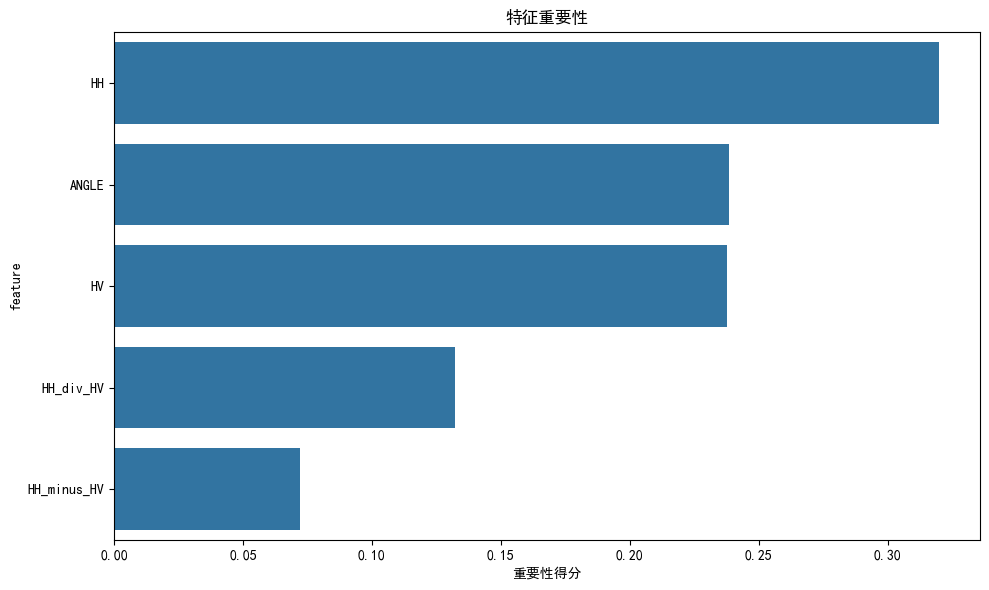


评估模型性能...

分类报告:
              precision    recall  f1-score   support

         ice       1.00      1.00      1.00     92055
        lead       1.00      1.00      1.00     77530
    refrozen       1.00      1.00      1.00     39791

    accuracy                           1.00    209376
   macro avg       1.00      1.00      1.00    209376
weighted avg       1.00      1.00      1.00    209376



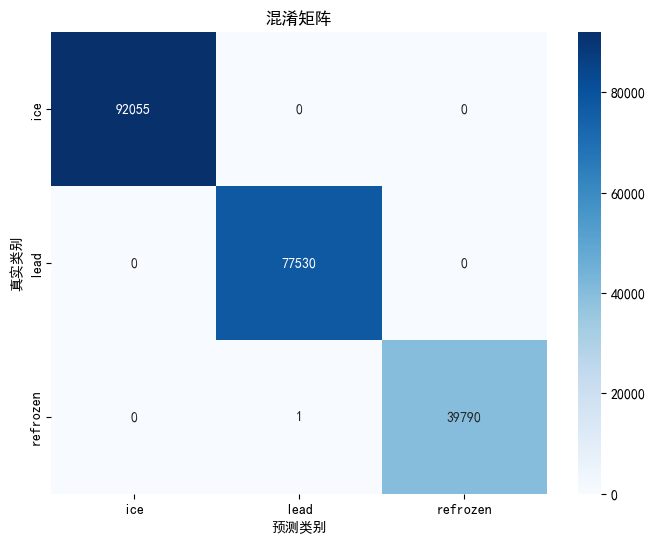

In [14]:
# 6. 训练最终模型
final_model = classifier.train_final_model(X, y, best_model)
evaluation_report = classifier.evaluate_model(X, y)

In [33]:
X, y = classifier.prepare_training_data(samples)


准备训练数据...
实际使用的特征: ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE']
特征矩阵形状: (697919, 5)
目标变量形状: (697919,)


# 占用内存过大处理，目前还没解决，先往上选择少波段进行分类


In [18]:
import os
output_dir = r"F:\NWP\Classification Result" 
# 8. 对masked Sentinel-1影像进行分类
tiff_path = r"F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230412T121730_20230412T121835_048063_05C70C_40A9_EW_HH_HV_angle_int16x100_87caa6ee_1_processed.tif"
output_path = os.path.join(output_dir, f"ice_classification_{selected_combination}.tif")
visualization_path = os.path.join(output_dir, f"classification_visualization_{selected_combination}.png")

print(f"\n5. 开始分类影像: {tiff_path}")
print(f"分类结果保存至: {output_path}")
print(f"可视化结果保存至: {visualization_path}")

try:
    file_size_mb = os.path.getsize(tiff_path) / 1024 / 1024
    print(f"输入文件大小: {file_size_mb:.1f} MB")
    
    # 根据文件大小自动选择分块大小
    if file_size_mb > 1000:  # > 1GB
        chunk_size = 512
        print("大文件检测：使用小分块处理")
    elif file_size_mb > 100:  # > 100MB
        chunk_size = 1024
        print("中等文件检测：使用中等分块处理")
    else:
        chunk_size = 2048
        print("小文件检测：使用大分块处理")
        
except FileNotFoundError:
    print(f"文件不存在: {tiff_path}")
    # return
except:
    chunk_size = 1024  # 默认分块大小

# 执行分类 (带内存优化)
classification_result, profile = classifier.classify_masked_sentinel1(
    tiff_path=tiff_path,
    output_path=output_path,
    chunk_size=chunk_size,
    use_memmap=True
)


5. 开始分类影像: F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230412T121730_20230412T121835_048063_05C70C_40A9_EW_HH_HV_angle_int16x100_87caa6ee_1_processed.tif
分类结果保存至: F:\NWP\Classification Result\ice_classification_comprehensive.tif
可视化结果保存至: F:\NWP\Classification Result\classification_visualization_comprehensive.png
输入文件大小: 648.1 MB
中等文件检测：使用中等分块处理


TypeError: Sentinel1IceClassifier.classify_masked_sentinel1() got an unexpected keyword argument 'chunk_size'